In [145]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt

In [146]:
# custom values
EDGE_LENGTH = 9e-3
ANGLE_OFFSET = np.pi/12
EDGE_OFFSET = 1e-5

# given paramters
RR = 0.06
BS = 0.004
RK = 0.02

POTENTIAL_ANGLE = 10 * np.pi/180   # in rad

POTENTIAL_1 = 1     # V
POTENTIAL_2 = -1    # V

In [147]:
# points on the inner circle
angle_5 = np.arccos(0.5*BS / RK)
height_5 = np.sin(angle_5) * RK

# points on the outer circle
angle_6 = np.arccos(0.5*BS / RR)
height_6 = np.sin(angle_6) * RR
angle_13 = np.pi - angle_6
angle_17 = angle_6 + np.pi
angle_3 = angle_13 + np.pi  # oder # angle_3 = -np.pi + angle_6

# potential parts on the outer circle
angle_11 = np.pi - 0.25*np.pi - 0.5*POTENTIAL_ANGLE
angle_12 = angle_11 + 0.5*POTENTIAL_ANGLE
angle_9 = angle_11 + np.pi
# angle_10 = 0 - 0.25*np.pi + 0.5*POTENTIAL_ANGLE
angle_10 = angle_12 + np.pi

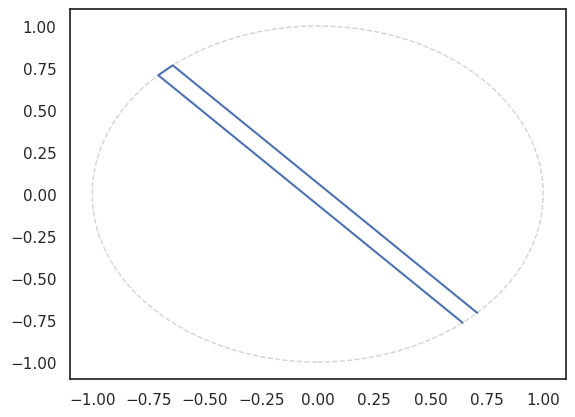

In [148]:
angles_to_plot = np.array([angle_9, angle_12, angle_11, angle_10])
x= np.cos(angles_to_plot)
y=np.sin(angles_to_plot)

fig, ax = plt.subplots()
ax.plot(x,y)
circle = plt.Circle((0, 0), 1, color='lightgray', fill=False, linestyle='--')  # unit circle
ax.add_patch(circle)
plt.show()

### Outer Circle

In [149]:
print(f"delta alpha: {POTENTIAL_ANGLE}")
print(f"Angle 9: {angle_9}")
print(f"Angle 10: {angle_10}")
print(f"Angle 11: {angle_11}")
print(f"Angle 12: {angle_12}")

delta alpha: 0.17453292519943295
Angle 9: 5.410520681182422
Angle 10: 5.497787143782138
Angle 11: 2.2689280275926285
Angle 12: 2.356194490192345


In [150]:
nodes, elements = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=0, a_max=angle_11)

# from p9 to p12
nodes1, elements1 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH/5, a_min=angle_11, a_max=angle_12)

nodes2, elements2 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_12, a_max=angle_9)

nodes3, elements3 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH/5, a_min=angle_9, a_max=angle_10)

nodes4, elements4 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_10, a_max=np.pi*2)

# nodes5, elements5 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_9, a_max=np.pi*2)

nodes, elements = mt.AddMultipleSegments(nodes, nodes1, nodes2, nodes3, nodes4)

# from p12 to p11
# nodes2, elements2 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_10, a_max=angle_11)
# nodes, elements = mt.AddSegments(nodes, nodes2)

# from p11 to p10
# nodes3, elements3 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_11, a_max=angle_12)
# nodes, elements = mt.AddSegments(nodes, nodes3)

# from p9 to p10
# nodes4, elements4 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_9, a_max=angle_10)
# nodes, elements = mt.AddSegments(nodes, nodes4)

### Inner Circle

In [151]:
nodes8, elements8 = mt.CircleSegments([0,0], RK, edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes8, elements8)

# from p6 to p5
nodes9, elements9 = mt.LineSegments([0.5*BS, height_6-EDGE_OFFSET], [0.5*BS, height_5], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes9, elements9)

# from p13 to p14
nodes10, elements10 = mt.LineSegments([-0.5*BS, height_6-EDGE_OFFSET], [-0.5*BS, height_5], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes10, elements10)

# from p3 to p4
nodes11, elements11 = mt.LineSegments([0.5*BS, -height_6-EDGE_OFFSET], [0.5*BS, -height_5], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes11, elements11)

# from p17 to p16
nodes12, elements12 = mt.LineSegments([-0.5*BS, -height_6-EDGE_OFFSET], [-0.5*BS, -height_5], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes12, elements12)

### Create Mesh

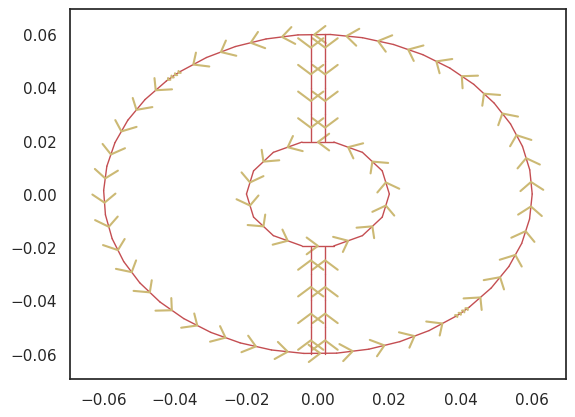

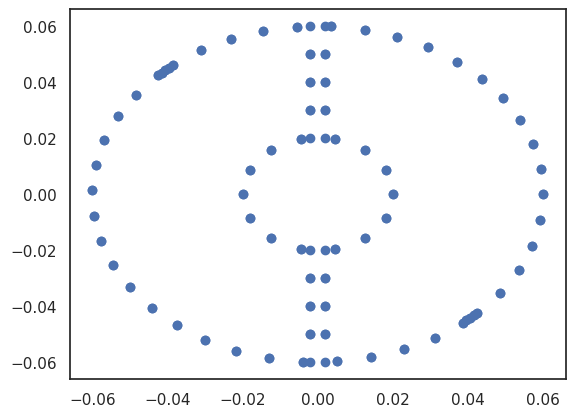

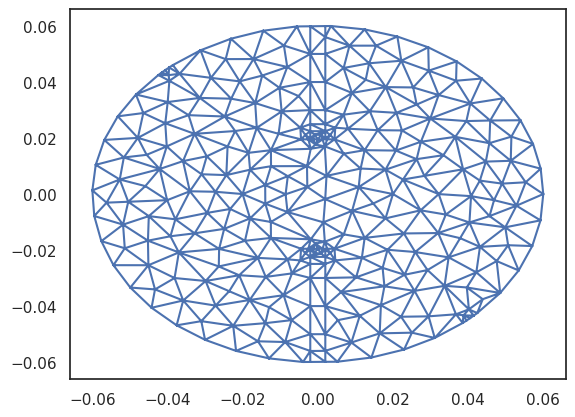

In [152]:
mt.PlotBoundary(nodes, elements, btype="Segments")
plt.show()
mt.PlotBoundary(nodes, elements, btype="Nodes")
plt.show()
knots, triangles,BouE,li_BE,bou_elem,CuE,li_CE = mt.DoTriMesh(nodes, elements, edge_length=EDGE_LENGTH)

### Get Boundaries

In [153]:
def get_xy_from_angle(angle, radius):
    y = np.sin(angle) * radius 
    x = np.cos(angle) * radius
    return x,y

x_p9, y_p9 = get_xy_from_angle(angle_9, RR)
x_p11, y_p11 = -x_p9, -y_p9

x_p10, y_p10 = get_xy_from_angle(angle_10, RR)
x_p12, y_p12 = -x_p10, -y_p10

x_p6, y_p6 = get_xy_from_angle(angle_6, RR)
x_p13, y_p13 = -x_p6, y_p6

x_p3, y_p3= x_p6, -y_p6
x_p17, y_p17 = x_p13, -y_p13

x_p5, y_p5 = get_xy_from_angle(angle_5, RR)
x_p4, y_p4 = x_p5, -y_p5

x_p14, y_p14 = -x_p5, y_p5
x_p16, y_p16 = x_p14, -y_p14

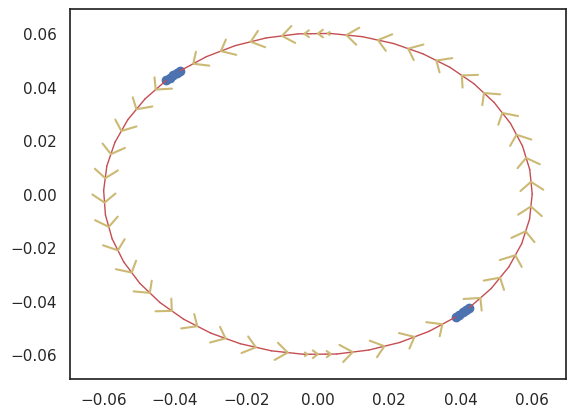

In [154]:
# randkurve dirichlet
Ps=[[x_p9,y_p9],[x_p10,y_p10],[-x_p9,-y_p9],[-x_p10,-y_p10]]
bseg_d=mt.RetrieveSegments(knots,BouE,li_BE,Ps,['Nodes', "Nodes", 'Nodes', "Nodes"])
mt.PlotBoundary(knots,bseg_d[0],'Nodes')
mt.PlotBoundary(knots,bseg_d[2],'Nodes')
# plt.show()

# Randkurven robin
Ps=[[x_p10,y_p10],[x_p11,y_p11],
    [x_p12,y_p12],[x_p9, y_p9],
    [x_p6, y_p6], [x_p5, y_p5]
    #   [x_p3, y_p3], [x_p9, y_p9]
]
bseg=mt.RetrieveSegments(knots,BouE,li_BE,Ps,[
    'Segments', 'Segments', 'Segments', 'Segments', 'Segments',
    # 'Segments', 'Segments', 'Segments'
])
mt.PlotBoundary(knots,bseg[0],'Segments')
mt.PlotBoundary(knots,bseg[2],'Segments')
plt.show()